<a href="https://colab.research.google.com/github/Erandi-Hans/Model-Traning-2/blob/main/titanic.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


In [5]:
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 100

In [6]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [7]:
import pandas as pd

file_path = (
    "/content/drive/MyDrive/House_Price_Prediction_Model_Training1/titanic.csv"
)

df = pd.read_csv(file_path)
print(f"Loaded: {df.shape[0]} rows x {df.shape[1]} columns")
df.head()

Loaded: 891 rows x 12 columns


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
titanic = sns.load_dataset('titanic')
print(f"Loaded: {titanic.shape[0]} rows x {titanic.shape[1]} columns")
titanic[['survived','pclass','sex','age','fare','embarked','sibsp','parch']].head()

Loaded: 891 rows x 15 columns


,survived,pclass,sex,age,fare,embarked,sibsp,parch
0,0,3,male,22.0,7.2500,S,1,0
1,1,1,female,38.0,71.2833,C,1,0
2,1,3,female,26.0,7.9250,S,0,0
3,1,1,female,35.0,53.1000,S,1,0
4,0,3,male,35.0,8.0500,S,0,0


In [15]:
# Keep the columns that matter, drop the rest
t = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'embarked', 'sibsp', 'parch']].copy()

print("Missing values:\n", t.isnull().sum())

# age: right-skewed -> median. embarked: 2 missing -> mode.
t['age']      = t['age'].fillna(t['age'].median())
t['embarked'] = t['embarked'].fillna(t['embarked'].mode()[0])

# Encode categoricals
t['sex'] = (t['sex'] == 'male').astype(int)          # 1 = male, 0 = female
t = pd.get_dummies(t, columns=['embarked'], drop_first=True)

print("\nNulls after cleaning:", t.isnull().sum().sum())
t.head()

Missing values:
 survived      0
pclass        0
sex           0
age         177
fare          0
embarked      2
sibsp         0
parch         0
dtype: int64

Nulls after cleaning: 0


,survived,pclass,sex,age,fare,sibsp,parch,embarked_Q,embarked_S
0,0,3,1,22.0,7.2500,1,0,False,True
1,1,1,0,38.0,71.2833,1,0,False,False
2,1,3,0,26.0,7.9250,0,0,False,True
3,1,1,0,35.0,53.1000,1,0,False,True
4,0,3,1,35.0,8.0500,0,0,False,True


In [16]:
Xc = t.drop('survived', axis=1)
yc = t['survived']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    Xc, yc, test_size=0.2, random_state=42, stratify=yc)

scaler_c = StandardScaler()
Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled  = scaler_c.transform(Xc_test)

print(f"Train: {Xc_train.shape[0]} | Test: {Xc_test.shape[0]} | Survival rate: {yc.mean():.1%}")

Train: 712 | Test: 179 | Survival rate: 38.4%


In [19]:
#A Scorecard for classification models

In [17]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

clf_results = {}

def score_classifier(name, y_true, y_pred, plot_cm=True):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec  = recall_score(y_true, y_pred)
    f1   = f1_score(y_true, y_pred)
    clf_results[name] = {'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1': f1}
    print(f"{name:22s}  Acc={acc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")

    if plot_cm:
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(4, 3.5))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=['Died', 'Survived'], yticklabels=['Died', 'Survived'])
        plt.title(f"{name} - Confusion Matrix")
        plt.ylabel("Actual")
        plt.xlabel("Predicted")
        plt.tight_layout()
        plt.show()
    return acc, prec, rec, f1

In [20]:
#Logistic Regression

Logistic Regression     Acc=0.804  Precision=0.793  Recall=0.667  F1=0.724


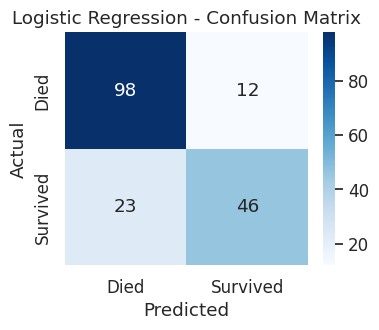

(0.8044692737430168,
 0.7931034482758621,
 0.6666666666666666,
 0.7244094488188977)

In [21]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(random_state=42)
log_reg.fit(Xc_train_scaled, yc_train)
y_pred_log = log_reg.predict(Xc_test_scaled)

score_classifier("Logistic Regression", yc_test, y_pred_log)

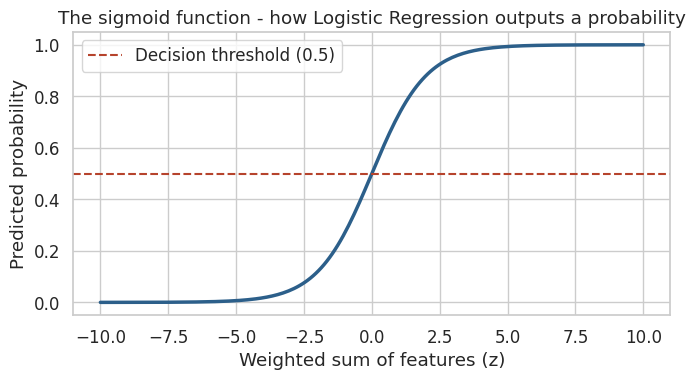

In [22]:
# The sigmoid squashes any input into a 0-1 probability - that's the whole trick
z = np.linspace(-10, 10, 200)
sigmoid = 1 / (1 + np.exp(-z))

plt.figure(figsize=(7, 4))
plt.plot(z, sigmoid, color='#2C5F8A', lw=2.5)
plt.axhline(0.5, color='#B6432C', ls='--', lw=1.5, label='Decision threshold (0.5)')
plt.xlabel("Weighted sum of features (z)")
plt.ylabel("Predicted probability")
plt.title("The sigmoid function - how Logistic Regression outputs a probability")
plt.legend()
plt.tight_layout()
plt.show()

In [24]:
#Decision Trees

In [23]:
# A tiny worked example of Gini impurity - the number the tree is actually optimising

def gini(labels):
    labels = np.array(labels)
    if len(labels) == 0:
        return 0
    p = np.array([np.mean(labels == c) for c in np.unique(labels)])
    return 1 - np.sum(p ** 2)

# Before any split: full mix of survivors and non-survivors
print(f"Gini BEFORE any split (whole training set): {gini(yc_train):.3f}")

# Try splitting on 'sex' and see how much purer the two branches become
male_labels   = yc_train[Xc_train['sex'] == 1]
female_labels = yc_train[Xc_train['sex'] == 0]
print(f"Gini AFTER splitting on sex==male:   {gini(male_labels):.3f}  (n={len(male_labels)})")
print(f"Gini AFTER splitting on sex==female: {gini(female_labels):.3f}  (n={len(female_labels)})")
print("\n-> 'sex' separates survivors from non-survivors well, which is why")
print("   a decision tree almost always picks it as (one of) its first split(s).")

Gini BEFORE any split (whole training set): 0.473
Gini AFTER splitting on sex==male:   0.302  (n=459)
Gini AFTER splitting on sex==female: 0.382  (n=253)

-> 'sex' separates survivors from non-survivors well, which is why
   a decision tree almost always picks it as (one of) its first split(s).


Decision Tree           Acc=0.777  Precision=0.809  Recall=0.551  F1=0.655


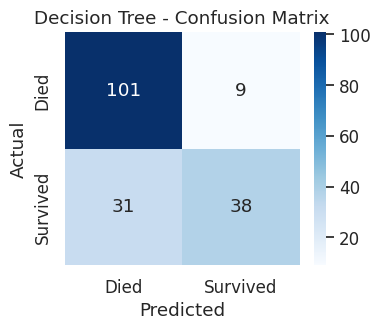

(0.776536312849162, 0.8085106382978723, 0.5507246376811594, 0.6551724137931034)

In [25]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

# max_depth limits how many questions deep it can go - keeps the tree readable
# and stops it memorising noise (overfitting)
dt_clf = DecisionTreeClassifier(max_depth=4, min_samples_leaf=10, random_state=42)
dt_clf.fit(Xc_train, yc_train)          # trees don't need scaled features
y_pred_dt = dt_clf.predict(Xc_test)

score_classifier("Decision Tree", yc_test, y_pred_dt)

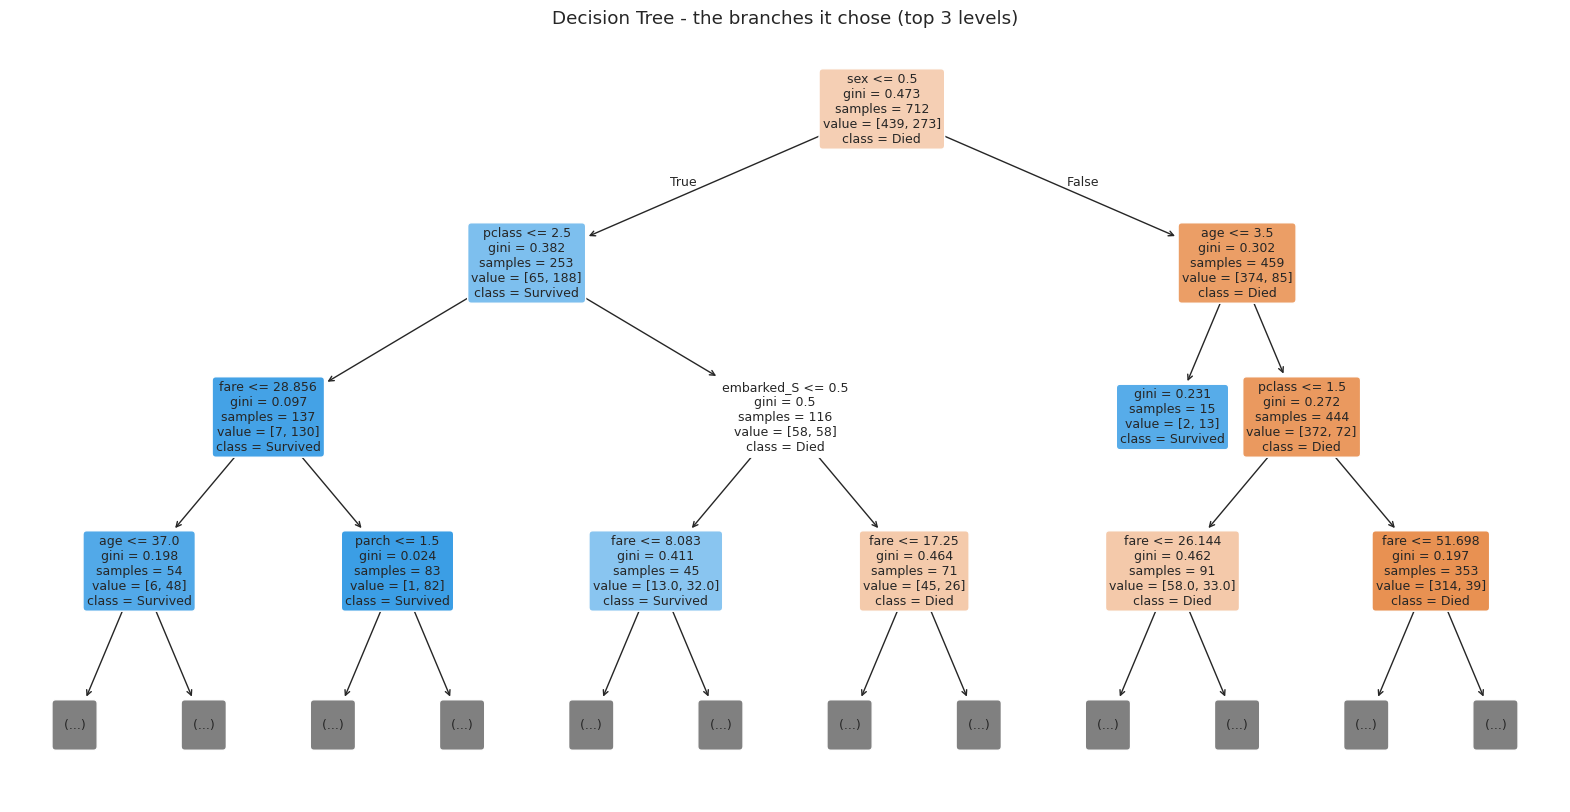

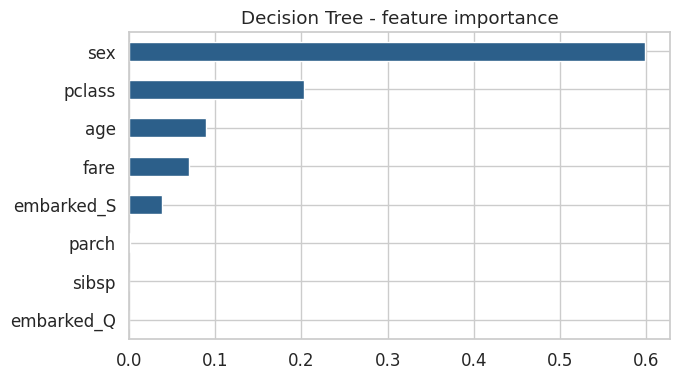

In [26]:
# Visualise the actual questions the tree learned to ask
plt.figure(figsize=(20, 10))
plot_tree(dt_clf, feature_names=Xc.columns, class_names=['Died', 'Survived'],
          filled=True, rounded=True, fontsize=9, max_depth=3)
plt.title("Decision Tree - the branches it chose (top 3 levels)")
plt.show()

# Which features did the tree lean on most, across all its splits?
importances = pd.Series(dt_clf.feature_importances_, index=Xc.columns).sort_values()
plt.figure(figsize=(7, 4))
importances.plot.barh(color='#2C5F8A')
plt.title("Decision Tree - feature importance")
plt.tight_layout()
plt.show()

Decision Tree           Acc=0.777  Precision=0.754  Recall=0.623  F1=0.683


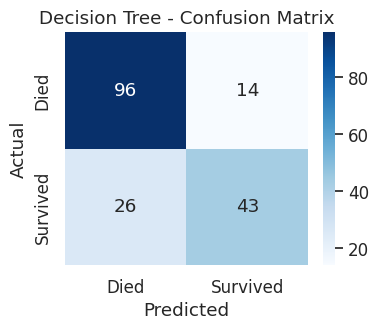

(0.776536312849162, 0.7543859649122807, 0.6231884057971014, 0.6825396825396826)

In [31]:
from sklearn.tree import DecisionTreeRegressor

dt_clf = DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, random_state=42)
dt_clf.fit(Xc_train, yc_train)
y_pred_dt = dt_clf.predict(Xc_test)

score_classifier("Decision Tree", yc_test, y_pred_dt)

In [32]:
#Random Forest

Random Forest           Acc=0.804  Precision=0.827  Recall=0.623  F1=0.711


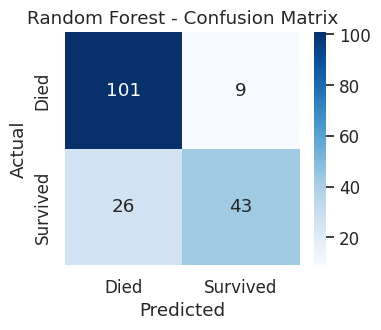

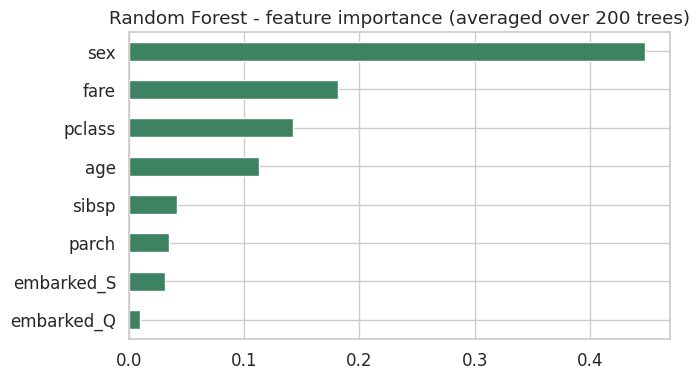

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(n_estimators=200, max_depth=6, min_samples_leaf=5, random_state=42)
rf_clf.fit(Xc_train, yc_train)
y_pred_rf = rf_clf.predict(Xc_test)

score_classifier("Random Forest", yc_test, y_pred_rf)

importances_rf = pd.Series(rf_clf.feature_importances_, index=Xc.columns).sort_values()
plt.figure(figsize=(7, 4))
importances_rf.plot.barh(color='#3D8361')
plt.title("Random Forest - feature importance (averaged over 200 trees)")
plt.tight_layout()
plt.show()

Random Forest           Acc=0.804  Precision=0.870  Recall=0.580  F1=0.696


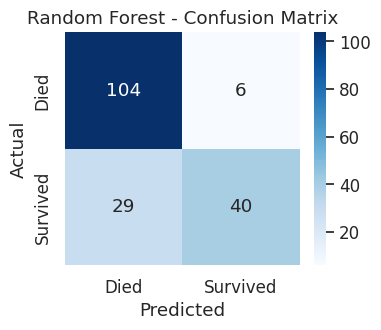

(0.8044692737430168,
 0.8695652173913043,
 0.5797101449275363,
 0.6956521739130435)

In [38]:
from sklearn.ensemble import RandomForestClassifier


rf_clf = RandomForestClassifier(n_estimators=100, max_depth=5, min_samples_leaf=10, random_state=42)
rf_clf.fit(Xc_train, yc_train)

y_pred_rf = rf_clf.predict(Xc_test)

score_classifier("Random Forest", yc_test, y_pred_rf)

In [39]:
#K-Nearest Neighbours(KNN)

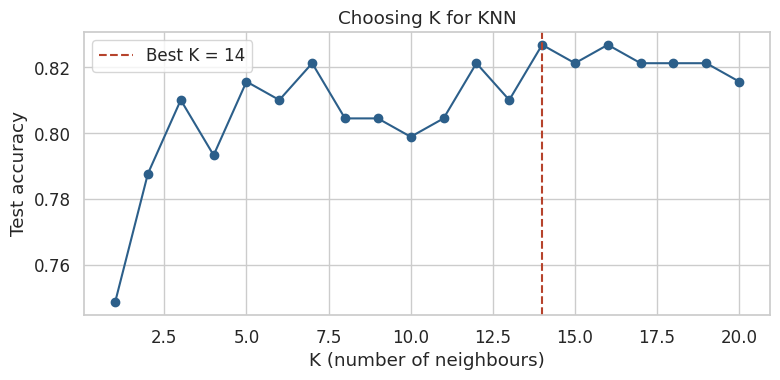

Best K: 14


In [40]:
from sklearn.neighbors import KNeighborsClassifier

# Try a range of K values and see which generalises best
k_values = range(1, 21)
accuracies = []
for k in k_values:
    knn_k = KNeighborsClassifier(n_neighbors=k)
    knn_k.fit(Xc_train_scaled, yc_train)
    accuracies.append(accuracy_score(yc_test, knn_k.predict(Xc_test_scaled)))

best_k = k_values[np.argmax(accuracies)]

plt.figure(figsize=(8, 4))
plt.plot(k_values, accuracies, marker='o', color='#2C5F8A')
plt.axvline(best_k, color='#B6432C', ls='--', label=f'Best K = {best_k}')
plt.xlabel("K (number of neighbours)")
plt.ylabel("Test accuracy")
plt.title("Choosing K for KNN")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Best K: {best_k}")

KNN                     Acc=0.827  Precision=0.865  Recall=0.652  F1=0.744


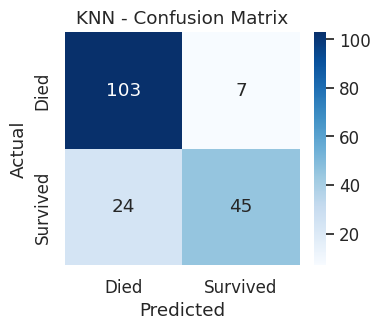

(0.8268156424581006, 0.8653846153846154, 0.6521739130434783, 0.743801652892562)

In [41]:
knn_clf = KNeighborsClassifier(n_neighbors=best_k)
knn_clf.fit(Xc_train_scaled, yc_train)
y_pred_knn = knn_clf.predict(Xc_test_scaled)

score_classifier("KNN", yc_test, y_pred_knn)

KNN (K=7)               Acc=0.821  Precision=0.785  Recall=0.739  F1=0.761


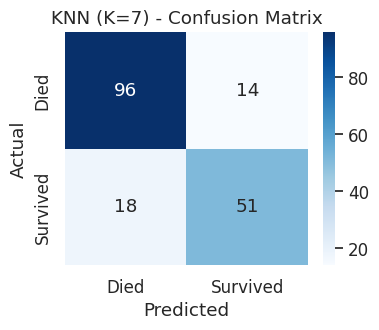

(0.8212290502793296,
 0.7846153846153846,
 0.7391304347826086,
 0.7611940298507462)

In [44]:
from sklearn.neighbors import KNeighborsClassifier


knn_clf = KNeighborsClassifier(n_neighbors=7)
knn_clf.fit(Xc_train_scaled, yc_train)
y_pred_knn = knn_clf.predict(Xc_test_scaled)

score_classifier("KNN (K=7)", yc_test, y_pred_knn)

In [46]:
#Classification models,side by side

In [45]:
clf_table = pd.DataFrame(clf_results).T.sort_values('F1', ascending=False)
clf_table.style.format('{:.3f}').background_gradient(cmap='Greens', subset=['F1'])

,Accuracy,Precision,Recall,F1
KNN (K=7),0.821,0.785,0.739,0.761
KNN,0.827,0.865,0.652,0.744
Logistic Regression,0.804,0.793,0.667,0.724
Random Forest,0.804,0.870,0.580,0.696
Decision Tree,0.777,0.754,0.623,0.683


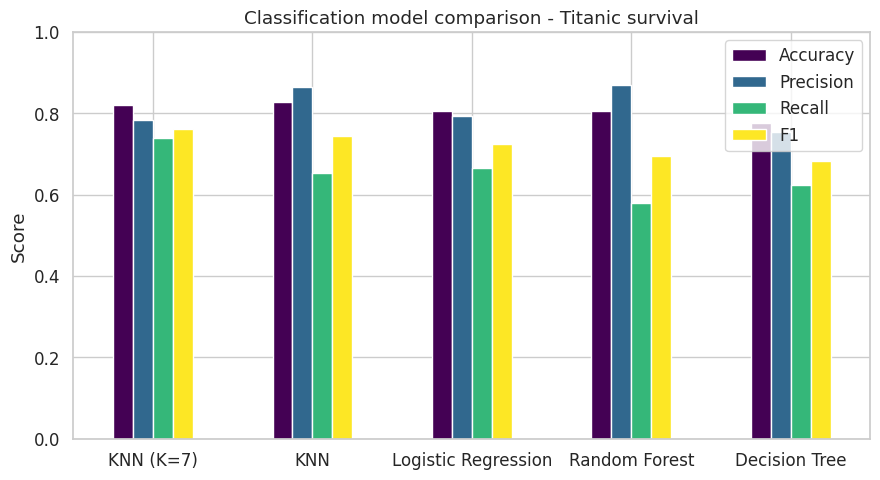

In [47]:
clf_table[['Accuracy', 'Precision', 'Recall', 'F1']].plot.bar(figsize=(9, 5), colormap='viridis')
plt.title("Classification model comparison - Titanic survival")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [53]:
# Neural Networks

Neural Network (MLP)    Acc=0.782  Precision=0.750  Recall=0.652  F1=0.698


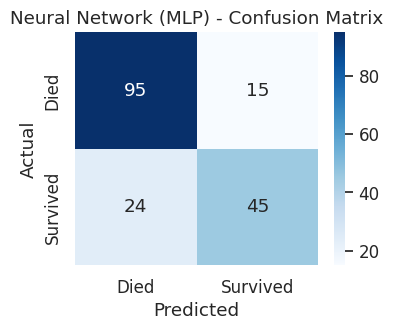

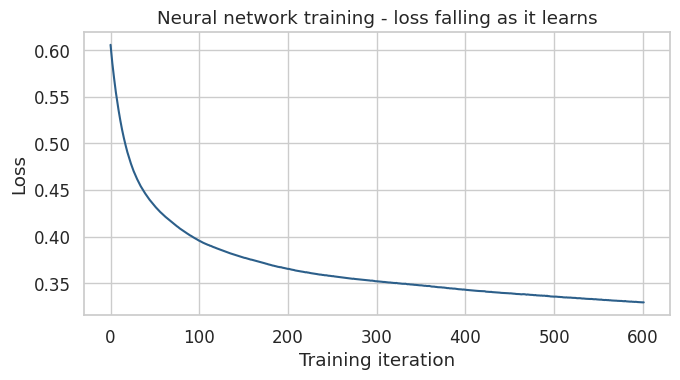

In [50]:
from sklearn.neural_network import MLPClassifier

# 2 hidden layers: 16 neurons, then 8. ReLU activation between them.
mlp_clf = MLPClassifier(hidden_layer_sizes=(16, 8), activation='relu',
                         max_iter=1000, random_state=42)
mlp_clf.fit(Xc_train_scaled, yc_train)
y_pred_mlp = mlp_clf.predict(Xc_test_scaled)

score_classifier("Neural Network (MLP)", yc_test, y_pred_mlp)

plt.figure(figsize=(7, 4))
plt.plot(mlp_clf.loss_curve_, color='#2C5F8A')
plt.xlabel("Training iteration")
plt.ylabel("Loss")
plt.title("Neural network training - loss falling as it learns")
plt.tight_layout()
plt.show()

Neural Network (MLP)    Acc=0.782  Precision=0.734  Recall=0.681  F1=0.707


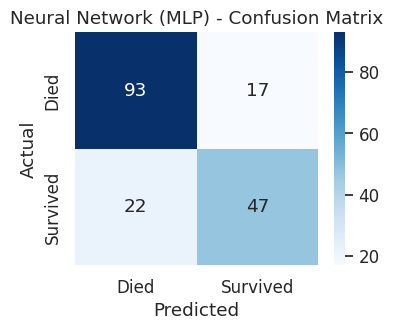

(0.7821229050279329, 0.734375, 0.6811594202898551, 0.706766917293233)

In [55]:
from sklearn.neural_network import MLPRegressor

mlp_reg = MLPClassifier(hidden_layer_sizes=(32, 16), activation='relu',
                        max_iter=2000, random_state=42)
mlp_reg.fit(Xc_train_scaled, yc_train)
y_pred_mlp_reg = mlp_reg.predict(Xc_test_scaled)

score_classifier("Neural Network (MLP)", yc_test, y_pred_mlp_reg)

In [56]:
print("\nCLASSIFICATION - predicting Titanic survival")
print("=" * 60)
display(clf_table.style.format('{:.3f}').background_gradient(cmap='Greens', subset=['F1']))


CLASSIFICATION - predicting Titanic survival


,Accuracy,Precision,Recall,F1
KNN (K=7),0.821,0.785,0.739,0.761
KNN,0.827,0.865,0.652,0.744
Logistic Regression,0.804,0.793,0.667,0.724
Random Forest,0.804,0.870,0.580,0.696
Decision Tree,0.777,0.754,0.623,0.683


In [57]:
print("=" * 55)
print("  DAY 2 - MODEL TRAINING COMPLETE")
print("=" * 55)
steps = [
    "Reviewed the 3 branches of ML: supervised, unsupervised, reinforcement",
    "Trained Linear Regression on housing price (regression)",
    "Trained Logistic Regression, Decision Tree, Random Forest, KNN on Titanic (classification)",
    "Explained exactly how a Decision Tree picks its branches (Gini impurity / variance reduction)",
    "Ran K-Means clustering on housing data with no labels (unsupervised)",
    "Trained a first Neural Network (MLP) for both classification and regression",
    "Compared every model on a like-for-like scorecard",
]
for s in steps:
    print(f"  - {s}")
print()
print("Next: Day 3 - hyperparameter tuning, NLP intro, and deploying the winning model.")

  DAY 2 - MODEL TRAINING COMPLETE
  - Reviewed the 3 branches of ML: supervised, unsupervised, reinforcement
  - Trained Linear Regression on housing price (regression)
  - Trained Logistic Regression, Decision Tree, Random Forest, KNN on Titanic (classification)
  - Explained exactly how a Decision Tree picks its branches (Gini impurity / variance reduction)
  - Ran K-Means clustering on housing data with no labels (unsupervised)
  - Trained a first Neural Network (MLP) for both classification and regression
  - Compared every model on a like-for-like scorecard

Next: Day 3 - hyperparameter tuning, NLP intro, and deploying the winning model.
